In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('sign_mnist_train.csv')
df_test = pd.read_csv('sign_mnist_test.csv')

In [3]:
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
from tensorflow.keras.utils import to_categorical

X_train = df_train.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = df_test.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0

y_train = to_categorical(df_train['label'])
y_test = to_categorical(df_test['label'])

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((27455, 28, 28, 1), (7172, 28, 28, 1), (27455, 25), (7172, 25))

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagenerator = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagenerator.fit(X_train)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(25,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
history = model.fit(
    datagenerator.flow(X_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(X_test,y_test)
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


429/429 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.2246 - loss: 2.5943 - val_accuracy: 0.8182 - val_loss: 0.6577
Epoch 2/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6663 - loss: 1.0206 - val_accuracy: 0.8236 - val_loss: 0.5367
Epoch 3/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7710 - loss: 0.6953 - val_accuracy: 0.9257 - val_loss: 0.2471
Epoch 4/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8280 - loss: 0.5149 - val_accuracy: 0.9400 - val_loss: 0.2005
Epoch 5/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8609 - loss: 0.4221 - val_accuracy: 0.9600 - val_loss: 0.1353
Epoch 6/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8811 - loss: 0.3477 - val_accuracy: 0.9681 - val_loss: 0.0971
Epoch 7/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8961 - loss: 0.3116 - val_accuracy: 0.9693 - val_loss: 0.0856
Epoch 8/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9115 - loss: 0.2656 - val_accuracy: 0.

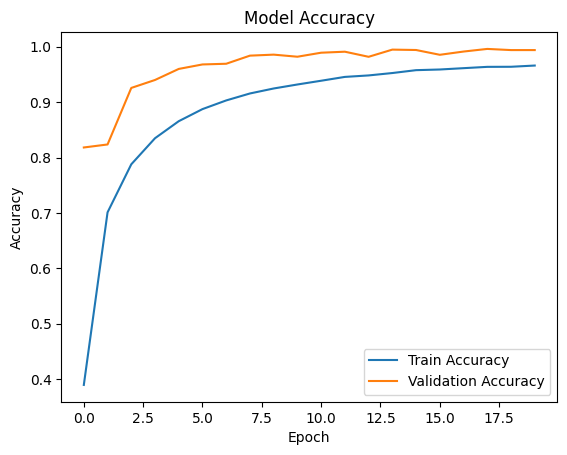

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
model.save('signlangmodel_CNN.keras')